<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

We will import the following libraries for the lab


In [2]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

<ipython-input-2-b7d446354769>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


This function is to plot the confusion matrix.


In [3]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [4]:
from js import fetch
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp1 = await fetch(URL1)
text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
data = pd.read_csv(text1)

In [5]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

In [7]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [8]:
# 1. Extract the column as a Pandas Series and convert it to a NumPy array
Y = data['Class'].to_numpy()

# 2. Verify the conversion and type output
print(f"Variable type: {type(Y)}")
print(f"First 5 elements of array Y: {Y[:5]}")

Variable type: <class 'numpy.ndarray'>
First 5 elements of array Y: [0 0 0 0 0]


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [9]:
# students get this 
from sklearn import preprocessing

# 1. Initialize the StandardScaler object
transform = preprocessing.StandardScaler()

# 2. Fit to the data and transform it, reassigning back to variable X
X = transform.fit_transform(X)

# 3. Verify the standardization
# After standardization, the mean of each feature should be ~0 and the variance/std should be 1
print("Shape of standardized matrix X:", X.shape)
print("Mean of the first feature:", X[:, 0].mean().round(4))
print("Standard deviation of the first feature:", X[:, 0].std().round(4))

Shape of standardized matrix X: (90, 83)
Mean of the first feature: 0.0
Standard deviation of the first feature: 1.0


We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [10]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2, 
    random_state=2
)

# Verify the dimensions of the resulting data splits
print("Dataset Splitting Summary:")
print(f"X_train shape: {X_train.shape} | Y_train shape: {Y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | Y_test shape:  {Y_test.shape}")

Dataset Splitting Summary:
X_train shape: (72, 83) | Y_train shape: (72,)
X_test shape:  (18, 83)  | Y_test shape:  (18,)


we can see we only have 18 test samples.


In [11]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter search space dictionary
parameters = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# 2. Create a Logistic Regression object
lr = LogisticRegression()

# 3. Create a GridSearchCV object with 10-fold cross-validation
logreg_cv = GridSearchCV(
    estimator=lr,
    param_grid=parameters,
    cv=10
)

# 4. Fit the cross-validation object to find the best parameters
logreg_cv.fit(X_train, Y_train)

# 5. Output the optimal parameters and validation results
print("Tuned Hyperparameters (Best Parameters):", logreg_cv.best_params_)
print("Best Cross-Validation Accuracy Score:     ", logreg_cv.best_score_.round(4))

Tuned Hyperparameters (Best Parameters): {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy Score:      0.8464


In [13]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [14]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [15]:
# Calculate accuracy score on the holdout test data split
test_accuracy = logreg_cv.score(X_test, Y_test)

print(f"Logistic Regression Test Accuracy Score: {test_accuracy:.4f}")

Logistic Regression Test Accuracy Score: 0.8333


Lets look at the confusion matrix:


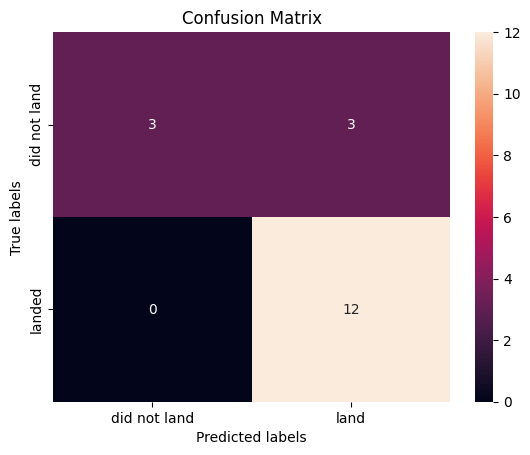

In [16]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import numpy as np

# 1. Define the hyperparameter search space dictionary for SVM
parameters = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}

# 2. Create a Support Vector Machine classifier object
svm = SVC()

# 3. Create a GridSearchCV object with 10-fold cross-validation
svm_cv = GridSearchCV(
    estimator=svm,
    param_grid=parameters,
    cv=10
)

# 4. Fit the cross-validation engine to find the optimal tuning parameters
svm_cv.fit(X_train, Y_train)

# 5. Output the optimal parameters and validation metrics
print("Tuned Hyperparameters (Best Parameters):", svm_cv.best_params_)
print("Best Cross-Validation Accuracy Score:     ", svm_cv.best_score_.round(4))
svm = SVC()

Tuned Hyperparameters (Best Parameters): {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
Best Cross-Validation Accuracy Score:      0.8482


In [18]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [19]:
# Calculate accuracy score on the holdout test data split
svm_test_accuracy = svm_cv.score(X_test, Y_test)

print(f"Support Vector Machine Test Accuracy Score: {svm_test_accuracy:.4f}")

Support Vector Machine Test Accuracy Score: 0.8333


We can plot the confusion matrix


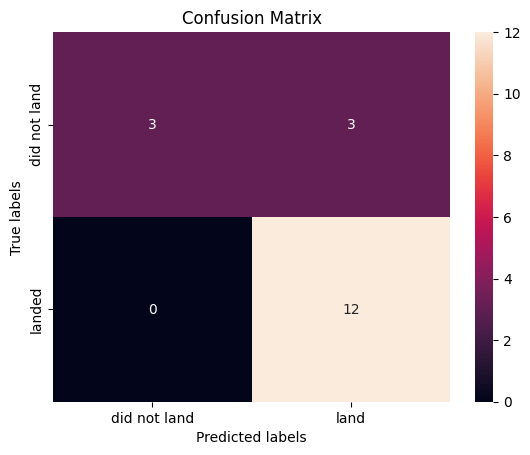

In [20]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter search space dictionary for the Decision Tree
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2*n for n in range(1, 10)],
    'max_features': ['sqrt', 'log2', None], # 'auto' is deprecated in modern scikit-learn versions
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# 2. Create a Decision Tree classifier object
tree = DecisionTreeClassifier()

# 3. Create a GridSearchCV object with 10-fold cross-validation
tree_cv = GridSearchCV(
    estimator=tree,
    param_grid=parameters,
    cv=10
)

# 4. Fit the cross-validation engine to find the optimal tuning parameters
tree_cv.fit(X_train, Y_train)

# 5. Output the optimal parameters and validation metrics
print("Tuned Hyperparameters (Best Parameters):", tree_cv.best_params_)
print("Best Cross-Validation Accuracy Score:     ", tree_cv.best_score_.round(4))

Tuned Hyperparameters (Best Parameters): {'criterion': 'gini', 'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
Best Cross-Validation Accuracy Score:      0.8893


In [22]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
accuracy : 0.8892857142857145


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [23]:
# Calculate accuracy score on the holdout test data split
tree_test_accuracy = tree_cv.score(X_test, Y_test)

print(f"Decision Tree Test Accuracy Score: {tree_test_accuracy:.4f}")

Decision Tree Test Accuracy Score: 0.8333


We can plot the confusion matrix


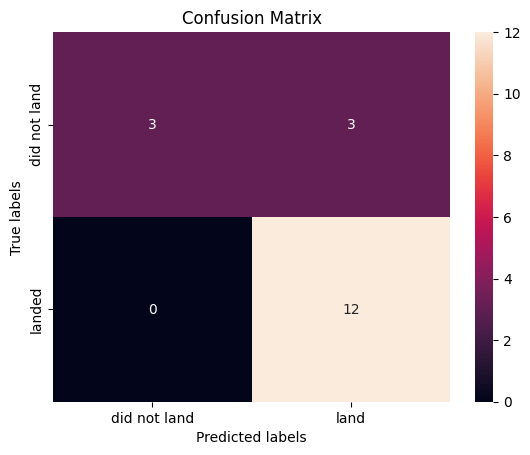

In [24]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter search space dictionary for KNN
parameters = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2] # p=1 maps to Manhattan distance, p=2 maps to Euclidean distance
}

# 2. Create a K-Nearest Neighbors classifier object
knn = KNeighborsClassifier()

# 3. Create a GridSearchCV object with 10-fold cross-validation
knn_cv = GridSearchCV(
    estimator=knn,
    param_grid=parameters,
    cv=10
)

# 4. Fit the cross-validation engine to find the optimal tuning parameters
knn_cv.fit(X_train, Y_train)

# 5. Output the optimal parameters and validation metrics
print("Tuned Hyperparameters (Best Parameters):", knn_cv.best_params_)
print("Best Cross-Validation Accuracy Score:     ", knn_cv.best_score_.round(4))

Tuned Hyperparameters (Best Parameters): {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1, 'weights': 'uniform'}
Best Cross-Validation Accuracy Score:      0.8482


In [26]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1, 'weights': 'uniform'}
accuracy : 0.8482142857142858


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [27]:
# Calculate accuracy score on the holdout test data split
knn_test_accuracy = knn_cv.score(X_test, Y_test)

print(f"K-Nearest Neighbors Test Accuracy Score: {knn_test_accuracy:.4f}")

K-Nearest Neighbors Test Accuracy Score: 0.8333


We can plot the confusion matrix


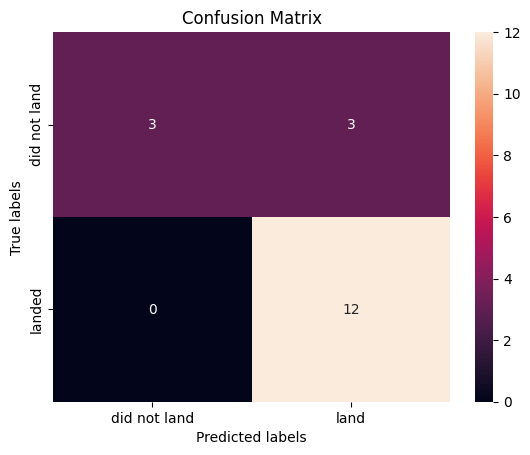

In [28]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12


Find the method performs best:


=== Model Performance Comparison ===
                 Model  Train CV Accuracy  Test Accuracy
   Logistic Regression           0.846429       0.833333
Support Vector Machine           0.848214       0.833333
         Decision Tree           0.889286       0.833333
   K-Nearest Neighbors           0.848214       0.833333

-------------------------------------------------------------
CONCLUSION: The best performing method on the test data is the Logistic Regression 
with a Test Accuracy of 83.33%.
-------------------------------------------------------------


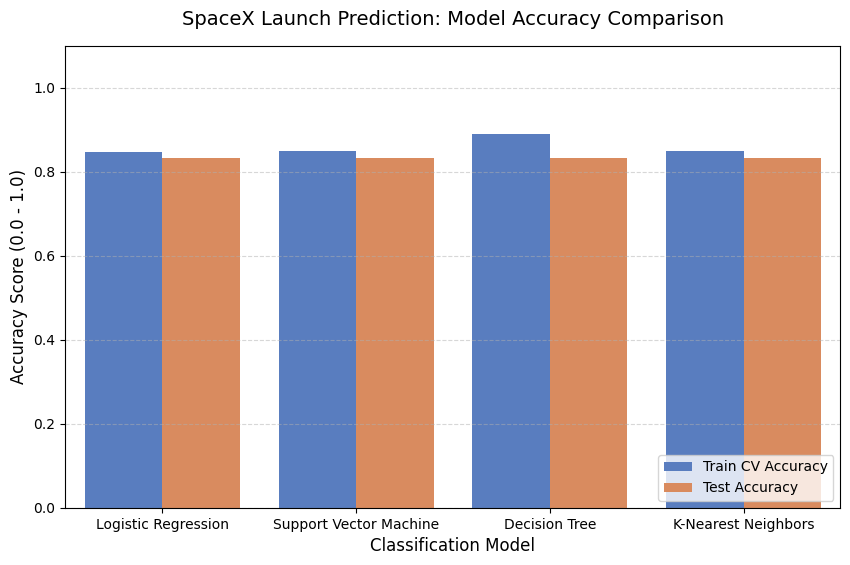

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compile the scores from all 4 models into a dictionary
model_performance = {
    'Model': ['Logistic Regression', 'Support Vector Machine', 'Decision Tree', 'K-Nearest Neighbors'],
    'Train CV Accuracy': [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_],
    'Test Accuracy': [logreg_cv.score(X_test, Y_test), svm_cv.score(X_test, Y_test), 
                      tree_cv.score(X_test, Y_test), knn_cv.score(X_test, Y_test)]
}

# 2. Convert to a DataFrame for clean formatting and plotting
performance_df = pd.DataFrame(model_performance)

# Display the performance summary table
print("=== Model Performance Comparison ===")
print(performance_df.to_string(index=False))

# 3. Find and print the best method based on Test Accuracy
best_test_idx = performance_df['Test Accuracy'].idxmax()
best_model_name = performance_df.loc[best_test_idx, 'Model']
best_model_score = performance_df.loc[best_test_idx, 'Test Accuracy']

print("\n-------------------------------------------------------------")
print(f"CONCLUSION: The best performing method on the test data is the {best_model_name} ")
print(f"with a Test Accuracy of {best_model_score * 100:.2f}%.")
print("-------------------------------------------------------------")

# 4. Melt the DataFrame to create a grouped side-by-side bar chart
melted_df = pd.melt(performance_df, id_vars="Model", var_name="Metric", value_name="Accuracy")

# 5. Plot the final comparison visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x="Model", y="Accuracy", hue="Metric", palette="muted")

plt.title("SpaceX Launch Prediction: Model Accuracy Comparison", fontsize=14, pad=15)
plt.xlabel("Classification Model", fontsize=12)
plt.ylabel("Accuracy Score (0.0 - 1.0)", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')

plt.show()

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
